<a href="https://colab.research.google.com/github/hetanshipatel/healthcare-ai-modelling-framework/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01_data_exploration.ipynb
## Computational Decision Modeling Framework

**Objective:**  
This notebook demonstrates the first step in building a research-grade AI framework: programmatic dataset acquisition, loading, and initial exploration.  

**Dataset:**  
- Heart Disease Dataset (Kaggle: johnsmith88/heart-disease-dataset)  
- Domain: Healthcare / Risk Modelling  

**Purpose:**  
1. Setup Kaggle API credentials for reproducible dataset access  
2. Download dataset programmatically  
3. Load CSV into Pandas DataFrame  
4. Perform basic exploratory data analysis (EDA)  
5. Visualize target distribution  

This notebook provides the foundation for subsequent preprocessing, feature engineering, and machine learning modeling.

In [2]:
# Step 1: Setup Kaggle API in Colab
# Using environment variable to store API key securely
# This ensures reproducible dataset downloads without manual uploads
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ed3b067ca6163c2d2af7ac4b9226ac69'

In [3]:
# Step 2: Install Kaggle CLI package
# Required to download datasets programmatically
!pip install kaggle --quiet

In [7]:
# Step 3: Create kaggle.json credentials file
# Kaggle CLI expects credentials to be in /root/.kaggle/kaggle.json
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_json = {
    "username": "hetanshipatel72 ",
    "key": os.environ['KAGGLE_API_TOKEN']
}

# Write kaggle.json file
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
os.chmod("/root/.kaggle/kaggle.json", 600)

In [8]:
# Step 4: Download dataset via Kaggle API
# -p data : store in 'data/' folder
# --unzip : automatically extract the zip file
# This ensures workflow reproducibility
!kaggle datasets download -d johnsmith88/heart-disease-dataset -p data --unzip

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
100% 6.18k/6.18k [00:00<00:00, 14.6MB/s]



In [9]:
# Step 5: Load CSV dataset into Pandas DataFrame
# This is essential for initial exploration and preprocessing
import pandas as pd

df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
# Step 6: Examine the dataset structure
# - Info about columns, data types
# - Missing values
# - Summary statistics
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


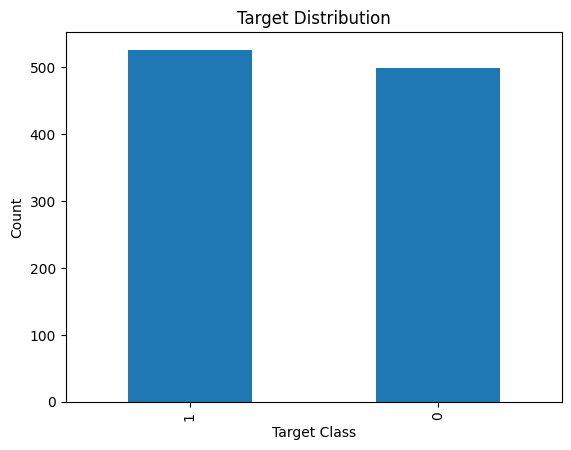

In [11]:
# Step 7: Visualize target distribution
# Quick insight into class balance, which is critical for ML model design
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()